In [ ]:
# Instala os pacotes
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib
!pip install pylatexenc

In [ ]:
# Importa as bibliotecas necessárias
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

In [ ]:
def create_bell_state(state_type):
    qc = QuantumCircuit(2)  # Cria um circuito de dois qubits

    # Aplica a porta Hadamard ao primeiro qubit
    qc.h(0)

    # Aplica a porta CNOT (com controle no qubit 0 e alvo no qubit 1)
    qc.cx(0, 1)

    # Modifica o estado conforme o tipo de Bell desejado
    if state_type == 'Phi-':
        qc.z(1)  # Aplica a porta Z no qubit 1
    elif state_type == 'Psi+':
        qc.x(1)  # Aplica a porta X no qubit 1
    elif state_type == 'Psi-':
        qc.z(1)  # Aplica a porta Z e a porta X no qubit 1
        qc.x(1)

    # Adiciona medições
    qc.measure_all()

    return qc

In [ ]:
# Cria os quatro estados de Bell
bell_states = ['Phi+', 'Phi-', 'Psi+', 'Psi-']

Circuito para o estado Phi+:


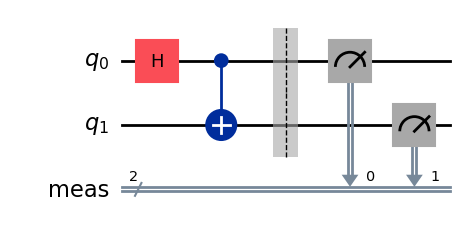

Circuito para o estado Phi-:


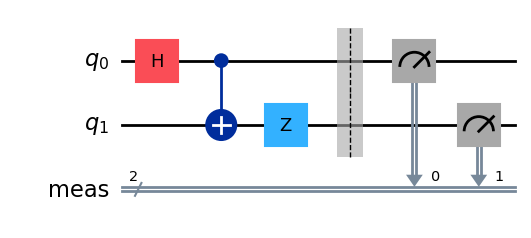

Circuito para o estado Psi+:


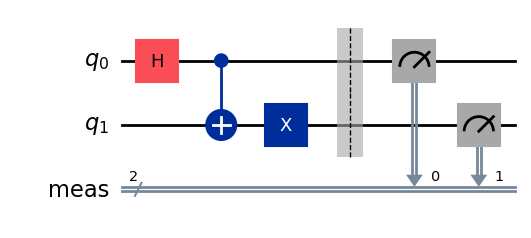

Circuito para o estado Psi-:


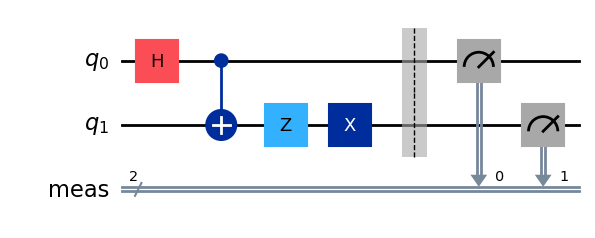

In [ ]:
for state in bell_states:
    qc = create_bell_state(state)
    print(f"Circuito para o estado {state}:")
    display(qc.draw('mpl'))

In [ ]:
# Loop para criar e simular cada estado de Bell
for state in bell_states:
    qc = create_bell_state(state)
    print(f"Histograma para o estado {state}:")

    # Executa o circuito no simulador
    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()

    # Pega os resultados da medição
    counts = result.get_counts()

    # Plota o histograma dos resultados
    print("Counts:", counts)
    # Visualize os resultados
    plot_histogram(counts)

Histograma para o estado Phi+:
Counts: {'00': 510, '11': 514}
Histograma para o estado Phi-:
Counts: {'11': 494, '00': 530}
Histograma para o estado Psi+:
Counts: {'10': 526, '01': 498}
Histograma para o estado Psi-:
Counts: {'10': 522, '01': 502}
